# Capstone Project\-Heatwave in Europe

Author: Md Humayain Kabir


--------------



<span style='font-size:x-large'>Heatwave and mortality in Europe Analysis Capstone Project</span>

Author: Md Humayain Kabir

Date: 29 March 2026

\#\# Environmental Research Question: 

1. How did heatwave evolve across Europe during 2000\-2023?
2. Who is most vulnerable, and what were the measurable health impacts \(excess mortality\)? 



## Loading Data

Data sources: Extreme Heatwave days data: [https://cds.climate.copernicus.eu/datasets/sis\-ecde\-climate\-indicators?tab=download](https://cds.climate.copernicus.eu/datasets/sis-ecde-climate-indicators?tab=download) 

Deaths by week and sex in the Europe: [https://ec.europa.eu/eurostat/databrowser/view/demo\_r\_mwk\_ts\_\_custom\_20693352/default/table](https://ec.europa.eu/eurostat/databrowser/view/demo_r_mwk_ts__custom_20693352/default/table) 


In [4]:
# Load libraries
library(readxl)
library(dplyr)
library(tidyr)
library(stringr)
library(ggplot2)
library(ISOweek)
library(zoo)


Attaching package: ‘zoo’




The following objects are masked from ‘package:base’:

    as.Date, as.Date.numeric




In [5]:
# Read the raw data

raw <- read_excel("mortality.xlsx", sheet = "Sheet 1", col_names = FALSE)

New names:
• `` -> `...1`
• `` -> `...2`
• `` -> `...3`
• `` -> `...4`
• `` -> `...5`
• `` -> `...6`
• `` -> `...7`
• `` -> `...8`
• `` -> `...9`
• `` -> `...10`
• `` -> `...11`
• `` -> `...12`
• `` -> `...13`
• `` -> `...14`
• `` -> `...15`
• `` -> `...16`
• `` -> `...17`
• `` -> `...18`
• `` -> `...19`
• `` -> `...20`
• `` -> `...21`
• `` -> `...22`
• `` -> `...23`
• `` -> `...24`
• `` -> `...25`
• `` -> `...26`
• `` -> `...27`
• `` -> `...28`
• `` -> `...29`
• `` -> `...30`
• `` -> `...31`
• `` -> `...32`
• `` -> `...33`
• `` -> `...34`
• `` -> `...35`
• `` -> `...36`
• `` -> `...37`
• `` -> `...38`
• `` -> `...39`
• `` -> `...40`
• `` -> `...41`
• `` -> `...42`
• `` -> `...43`
• `` -> `...44`
• `` -> `...45`
• `` -> `...46`
• `` -> `...47`
• `` -> `...48`
• `` -> `...49`
• `` -> `...50`
• `` -> `...51`
• `` -> `...52`
• `` -> `...53`
• `` -> `...54`
• `` -> `...55`
• `` -> `...56`
• `` -> `...57`
• `` -> `...58`
• `` -> `...59`
• `` -> `...60`
• `` -> `...61`
• `` -> `...62`
• `` -

In [6]:
#Extract the week headers from row 9
week_row <- raw[9, ] |> unlist(use.names = FALSE)

# Data columns start at col 3
data_cols <- 3:length(week_row)

# Keep only the actual week columns (not the empty flag columns)
value_cols <- data_cols[!is.na(week_row[data_cols]) & week_row[data_cols] != ""]
weeks <- week_row[value_cols]

In [7]:
#Extract the country rows
dat <- raw[11:49, ]

In [8]:
# Build a clean long dataset
geo_code  <- dat[[1]]
geo_label <- dat[[2]]

values_mat <- dat[, value_cols]

colnames(values_mat) <- weeks

deaths_long <- values_mat |>
  mutate(
    geo_code = geo_code,
    geo_label = geo_label
  ) |>
  pivot_longer(
    cols = -c(geo_code, geo_label),
    names_to = "week",
    values_to = "deaths"
  ) |>
  mutate(
    deaths = ifelse(deaths == ":", NA, deaths),
    deaths = as.numeric(deaths)
  )

In [9]:
# Convert Eurostat week string to a real date

deaths_long <- deaths_long |>
  mutate(
    week = trimws(week),
    week_start = ISOweek2date(paste0(week, "-1")),
    year = as.integer(substr(week, 1, 4)),
    week_num = as.integer(substr(week, 7, 8))
  )

In [10]:
# Fist check: look at coerage
coverage <- deaths_long |>
  group_by(geo_code, geo_label) |>
  summarise(
    n_weeks = n(),
    non_missing = sum(!is.na(deaths)),
    pct_available = round(100 * non_missing / n_weeks, 1),
    .groups = "drop"
  ) |>
  arrange(desc(pct_available))

coverage

geo_code,geo_label,n_weeks,non_missing,pct_available
<chr>,<chr>,<int>,<int>,<dbl>
ES,Spain,1361,1361,100.0
AT,Austria,1361,1358,99.8
FI,Finland,1361,1358,99.8
BE,Belgium,1361,1357,99.7
LU,Luxembourg,1361,1357,99.7
NL,Netherlands,1361,1357,99.7
SK,Slovakia,1361,1357,99.7
BG,Bulgaria,1361,1356,99.6
CH,Switzerland,1361,1356,99.6


Warning message:
“Removed 4 rows containing missing values or values outside the scale range
(`geom_line()`).”


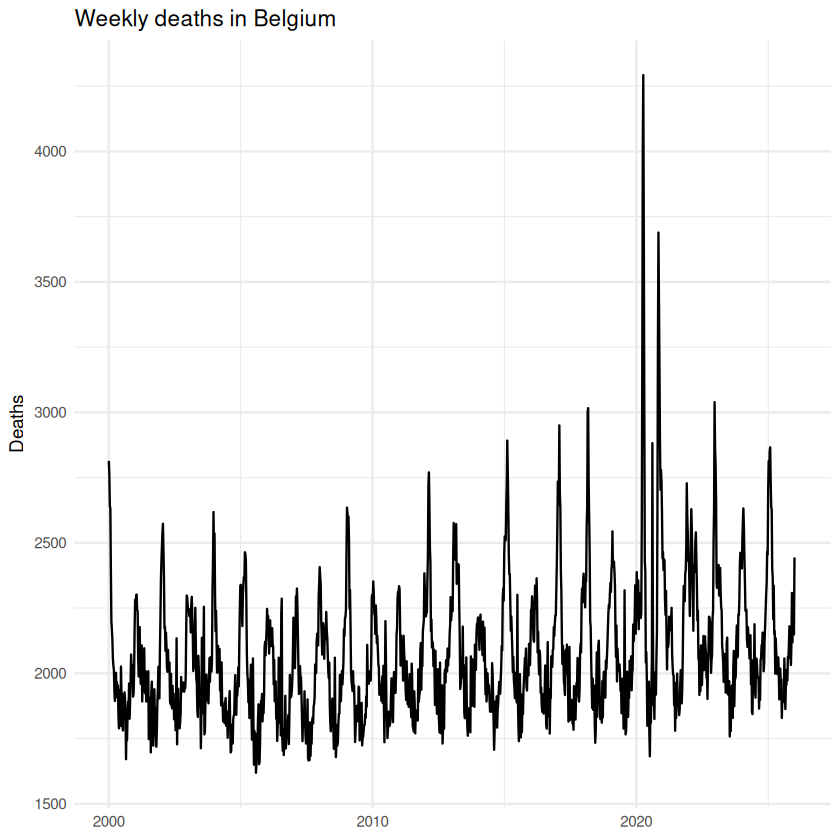

In [11]:
# Plot one country: Example-Belgium

deaths_long |>
  filter(geo_code == "BE") |>
  ggplot(aes(x = week_start, y = deaths)) +
  geom_line() +
  labs(
    title = "Weekly deaths in Belgium",
    x = NULL,
    y = "Deaths"
  ) +
  theme_minimal()

In [12]:
# Build a historical baseline
baseline <- deaths_long |>
  filter(year >= 2000, year <= 2019) |>
  group_by(geo_code, week_num) |>
  summarise(
    baseline_mean = mean(deaths, na.rm = TRUE),
    baseline_sd   = sd(deaths, na.rm = TRUE),
    .groups = "drop"
  )

In [13]:
# Join baseline and compute excess deaths

deaths_excess <- deaths_long |>
  left_join(baseline, by = c("geo_code", "week_num")) |>
  mutate(
    excess_deaths = deaths - baseline_mean,
    z_score = (deaths - baseline_mean) / baseline_sd
  )

In [14]:
deaths_excess

geo_code,geo_label,week,deaths,week_start,year,week_num,baseline_mean,baseline_sd,excess_deaths,z_score
<chr>,<chr>,<chr>,<dbl>,<date>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
EU27_2020,European Union - 27 countries (from 2020),2000-W01,NA,2000-01-03,2000,1,103468.6,8142.3378,NA,NA
EU27_2020,European Union - 27 countries (from 2020),2000-W02,NA,2000-01-10,2000,2,105075.8,10128.2872,NA,NA
EU27_2020,European Union - 27 countries (from 2020),2000-W03,NA,2000-01-17,2000,3,104521.6,7632.7610,NA,NA
EU27_2020,European Union - 27 countries (from 2020),2000-W04,NA,2000-01-24,2000,4,103604.4,7251.5305,NA,NA
EU27_2020,European Union - 27 countries (from 2020),2000-W05,NA,2000-01-31,2000,5,104308.8,7616.4982,NA,NA
EU27_2020,European Union - 27 countries (from 2020),2000-W06,NA,2000-02-07,2000,6,103025.8,5388.8100,NA,NA
EU27_2020,European Union - 27 countries (from 2020),2000-W07,NA,2000-02-14,2000,7,102981.2,6700.9493,NA,NA
EU27_2020,European Union - 27 countries (from 2020),2000-W08,NA,2000-02-21,2000,8,102639.8,7238.6731,NA,NA
EU27_2020,European Union - 27 countries (from 2020),2000-W09,NA,2000-02-28,2000,9,102749.0,8454.3787,NA,NA


In [15]:
# Focus on summer weeks

summer_df <- deaths_excess |>
  filter(week_num >= 22, week_num <= 38)

In [16]:
# Identify extreme mortality weeks

summer_df |>
  filter(z_score > 2) |>
  arrange(desc(z_score))

geo_code,geo_label,week,deaths,week_start,year,week_num,baseline_mean,baseline_sd,excess_deaths,z_score
<chr>,<chr>,<chr>,<dbl>,<date>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
AL,Albania,2020-W34,548,2020-08-17,2020,34,356.80000,7.981228,191.20000,23.956213
EU27_2020,European Union - 27 countries (from 2020),2022-W29,101900,2022-07-18,2022,29,82085.60000,984.797086,19814.40000,20.120287
RS,Serbia,2021-W37,2895,2021-09-13,2021,37,1737.25000,66.782345,1157.75000,17.336169
RO,Romania,2024-W29,6398,2024-07-15,2024,29,4427.80000,115.142086,1970.20000,17.111033
EL,Greece,2021-W31,3895,2021-08-02,2021,31,2345.40000,92.894026,1549.60000,16.681374
BG,Bulgaria,2021-W37,2900,2021-09-13,2021,37,1808.60000,69.768338,1091.40000,15.643199
RS,Serbia,2021-W38,2979,2021-09-20,2021,38,1787.35000,82.844988,1191.65000,14.384093
RO,Romania,2021-W38,6364,2021-09-20,2021,38,4396.60000,144.992414,1967.40000,13.568986
EL,Greece,2021-W37,2721,2021-09-13,2021,37,2051.60000,50.381544,669.40000,13.286611


In [17]:
# Compare known heatwave years, for example in 2003, 2015, and 2022

summer_df |>
  filter(geo_code %in% c("FR", "ES", "IT", "PT"), year %in% c(2003, 2015, 2022))

geo_code,geo_label,week,deaths,week_start,year,week_num,baseline_mean,baseline_sd,excess_deaths,z_score
<chr>,<chr>,<chr>,<dbl>,<date>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
ES,Spain,2003-W22,6914,2003-05-26,2003,22,6889.35,330.3936,24.65,0.07460799
ES,Spain,2003-W23,6805,2003-06-02,2003,23,6832.75,392.6577,-27.75,-0.07067224
ES,Spain,2003-W24,7690,2003-06-09,2003,24,6912.50,417.2167,777.50,1.86354018
ES,Spain,2003-W25,7727,2003-06-16,2003,25,6992.95,448.5021,734.05,1.63667006
ES,Spain,2003-W26,7363,2003-06-23,2003,26,6997.85,399.3491,365.15,0.91436287
ES,Spain,2003-W27,6650,2003-06-30,2003,27,6996.05,511.0539,-346.05,-0.67713019
ES,Spain,2003-W28,7120,2003-07-07,2003,28,6943.05,577.1407,176.95,0.30659767
ES,Spain,2003-W29,6855,2003-07-14,2003,29,6868.30,491.0551,-13.30,-0.02708454
ES,Spain,2003-W30,7188,2003-07-21,2003,30,6891.25,412.8839,296.75,0.71872498


In [18]:
# Summer anomaly table
summer_extremes <- deaths_excess |>
  filter(week_num >= 22, week_num <= 38) |>
  filter(!is.na(z_score)) |>
  arrange(desc(z_score))

head(summer_extremes, 20)

geo_code,geo_label,week,deaths,week_start,year,week_num,baseline_mean,baseline_sd,excess_deaths,z_score
<chr>,<chr>,<chr>,<dbl>,<date>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
AL,Albania,2020-W34,548,2020-08-17,2020,34,356.80000,7.981228,191.20000,23.956213
EU27_2020,European Union - 27 countries (from 2020),2022-W29,101900,2022-07-18,2022,29,82085.60000,984.797086,19814.40000,20.120287
RS,Serbia,2021-W37,2895,2021-09-13,2021,37,1737.25000,66.782345,1157.75000,17.336169
RO,Romania,2024-W29,6398,2024-07-15,2024,29,4427.80000,115.142086,1970.20000,17.111033
EL,Greece,2021-W31,3895,2021-08-02,2021,31,2345.40000,92.894026,1549.60000,16.681374
BG,Bulgaria,2021-W37,2900,2021-09-13,2021,37,1808.60000,69.768338,1091.40000,15.643199
RS,Serbia,2021-W38,2979,2021-09-20,2021,38,1787.35000,82.844988,1191.65000,14.384093
RO,Romania,2021-W38,6364,2021-09-20,2021,38,4396.60000,144.992414,1967.40000,13.568986
EL,Greece,2021-W37,2721,2021-09-13,2021,37,2051.60000,50.381544,669.40000,13.286611


Warning message:
“There were 4 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_weekly_excess = max(excess_deaths, na.rm = TRUE)`.
ℹ In group 1: `geo_code = "AD"` `geo_label = "Andorra"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 3 remaining warnings.”


Warning message:
“There were 8 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_z = max(z_score, na.rm = TRUE)`.
ℹ In group 1: `geo_code = "AD"` `geo_label = "Andorra"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 7 remaining warnings.”


# A tibble: 39 × 8
   geo_code  geo_label  summer_observed summer_expected summer_excess pct_excess
   <chr>     <chr>                <dbl>           <dbl>         <dbl>      <dbl>
 1 EU27_2020 European …         1553925        1384987.       168938.       12.2
 2 DE        Germany             323836         264405.        59431.       22.5
 3 ES        Spain               148549         115759.        32790.       28.3
 4 IT        Italy               219494         189730.        29764.       15.7
 5 FR        France              199634         176788         22846        12.9
 6 PL        Poland              131821         115472.        16349.       14.2
 7 NL        Netherlan…           51358          42875          8483        19.8
 8 PT        Portugal             38167          30755.         7412.       24.1
 9 EL        Greece               43308          37624.         5684.       15.1
10 AT        Austria              27535          23545.         3990.       16.9
# ℹ 29 mo

# A tibble: 39 × 6
   geo_code  geo_label         extreme_weeks very_extreme_weeks max_z max_excess
   <chr>     <chr>                     <int>              <int> <dbl>      <dbl>
 1 ES        Spain                        17                 15  8.34      4097.
 2 NL        Netherlands                  17                 14  5.72       650 
 3 DE        Germany                      17                 15  5.70      5278.
 4 EU27_2020 European Union -…            16                 12 20.1      19814.
 5 FR        France                       15                  8  9.55      2761.
 6 FI        Finland                      15                 14  7.05       307.
 7 CH        Switzerland                  15                 10  5.60       378.
 8 AT        Austria                      15                  7  4.15       442.
 9 PT        Portugal                     14                 10  7.20       906.
10 IE        Ireland                      14                 10  6.59       110.
# ℹ 29 mo

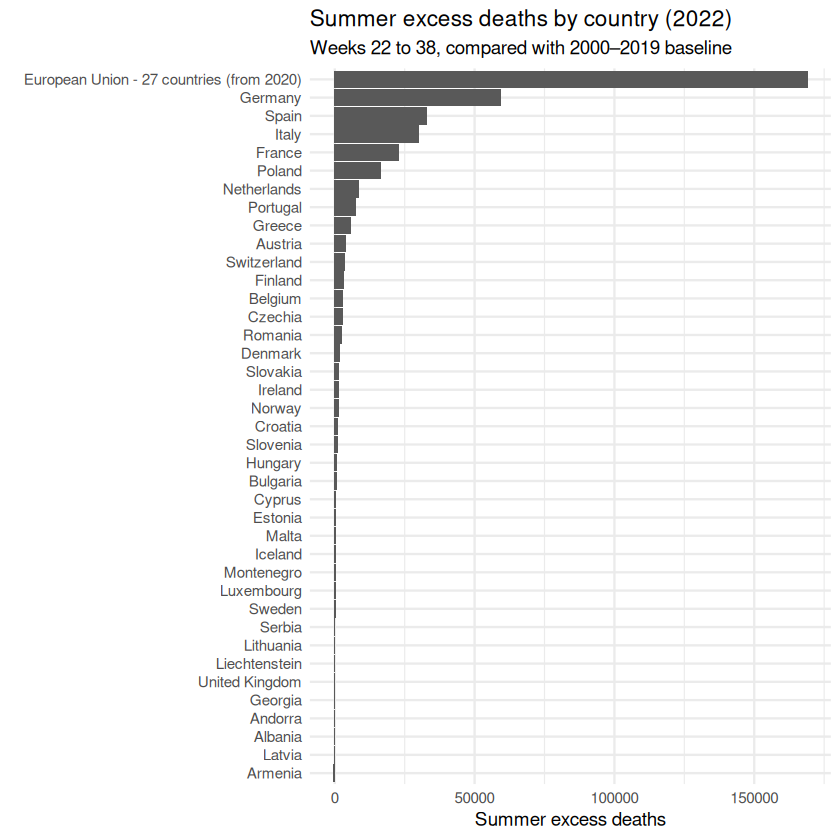

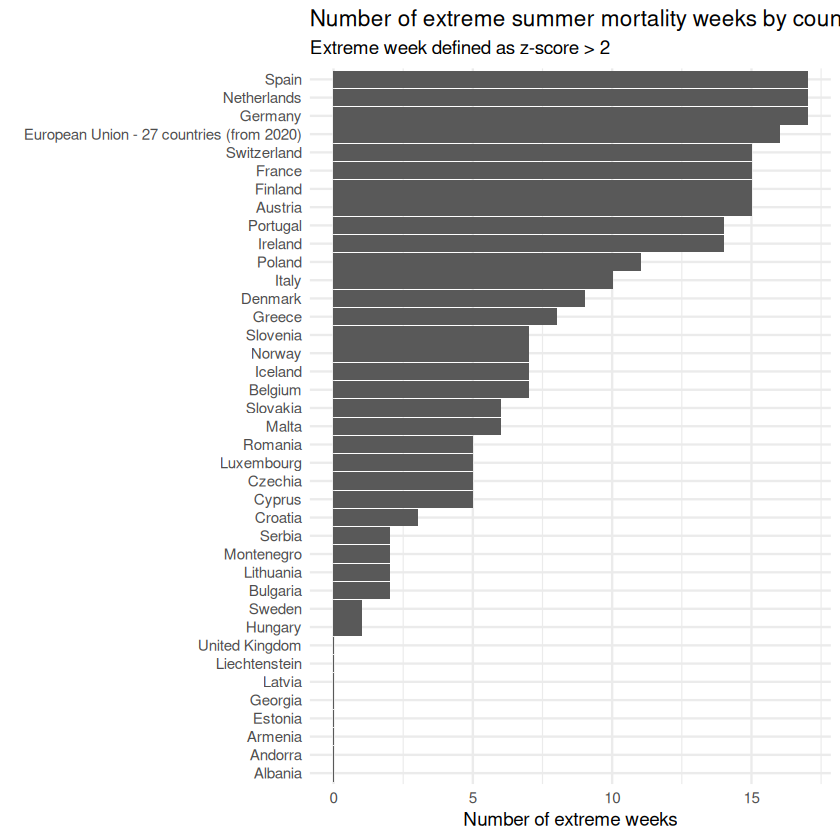

In [19]:
# Visualizaions

library(dplyr)
library(ggplot2)
library(forcats)

baseline <- deaths_long |>
  filter(year >= 2000, year <= 2019) |>
  group_by(geo_code, geo_label, week_num) |>
  summarise(
    baseline_mean = mean(deaths, na.rm = TRUE),
    baseline_sd   = sd(deaths, na.rm = TRUE),
    .groups = "drop"
  )

deaths_excess <- deaths_long |>
  left_join(baseline, by = c("geo_code", "geo_label", "week_num")) |>
  mutate(
    excess_deaths = deaths - baseline_mean,
    z_score = (deaths - baseline_mean) / baseline_sd
  )

summer_excess_2022 <- deaths_excess |>
  filter(year == 2022, week_num >= 22, week_num <= 38) |>
  group_by(geo_code, geo_label) |>
  summarise(
    summer_observed = sum(deaths, na.rm = TRUE),
    summer_expected = sum(baseline_mean, na.rm = TRUE),
    summer_excess   = sum(excess_deaths, na.rm = TRUE),
    pct_excess = 100 * (summer_observed - summer_expected) / summer_expected,
    max_weekly_excess = max(excess_deaths, na.rm = TRUE),
    avg_summer_z = mean(z_score, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(summer_excess))

summer_extremes_2022 <- deaths_excess |>
  filter(year == 2022, week_num >= 22, week_num <= 38) |>
  group_by(geo_code, geo_label) |>
  summarise(
    extreme_weeks = sum(z_score > 2, na.rm = TRUE),
    very_extreme_weeks = sum(z_score > 3, na.rm = TRUE),
    max_z = max(z_score, na.rm = TRUE),
    max_excess = max(excess_deaths, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(extreme_weeks), desc(max_z))

print(summer_excess_2022)
print(summer_extremes_2022)

ggplot(summer_excess_2022, aes(x = reorder(geo_label, summer_excess), y = summer_excess)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Summer excess deaths by country (2022)",
    subtitle = "Weeks 22 to 38, compared with 2000–2019 baseline",
    x = NULL,
    y = "Summer excess deaths"
  ) +
  theme_minimal()

ggplot(summer_extremes_2022, aes(x = reorder(geo_label, extreme_weeks), y = extreme_weeks)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Number of extreme summer mortality weeks by country (2022)",
    subtitle = "Extreme week defined as z-score > 2",
    x = NULL,
    y = "Number of extreme weeks"
  ) +
  theme_minimal()

Warning message:
“There were 12 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_weekly_excess = max(excess_deaths, na.rm = TRUE)`.
ℹ In group 2: `geo_code = "AL"` `geo_label = "Albania"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 11 remaining warnings.”


Warning message:
“There were 25 warnings in `summarise()`.
The first warning was:
ℹ In argument: `max_z = max(z_score, na.rm = TRUE)`.
ℹ In group 1: `geo_code = "AD"` `geo_label = "Andorra"`.
Caused by warning in `max()`:
! no non-missing arguments to max; returning -Inf
ℹ Run `dplyr::last_dplyr_warnings()` to see the 24 remaining warnings.”


# A tibble: 39 × 8
   geo_code geo_label   summer_observed summer_expected summer_excess pct_excess
   <chr>    <chr>                 <dbl>           <dbl>         <dbl>      <dbl>
 1 DE       Germany              278306         257112.        21194.       8.24
 2 ES       Spain                123416         112167.        11249.      10.0 
 3 PL       Poland               119478         113232.         6246.       5.52
 4 NL       Netherlands           43942          42126.         1816.       4.31
 5 AT       Austria               24758          23010.         1748.       7.60
 6 CH       Switzerland           20201          18623.         1578.       8.47
 7 CZ       Czechia               34013          32748.         1265.       3.86
 8 HR       Croatia               16550          15538.         1012.       6.52
 9 BE       Belgium               32220          31332.          888.       2.84
10 FI       Finland               15878          15170.          708.       4.66
# ℹ 29 mo

# A tibble: 39 × 6
   geo_code geo_label   extreme_weeks very_extreme_weeks max_z max_excess
   <chr>    <chr>               <int>              <int> <dbl>      <dbl>
 1 DE       Germany                 9                  2  4.87     3960. 
 2 ES       Spain                   7                  5  4.36     1715. 
 3 AT       Austria                 6                  4  4.10      321. 
 4 CZ       Czechia                 4                  2  8.67      633. 
 5 CH       Switzerland             4                  4  6.80      285. 
 6 PL       Poland                  4                  2  5.41     1270. 
 7 HR       Croatia                 4                  2  3.24      282. 
 8 FI       Finland                 4                  0  2.68      109. 
 9 IS       Iceland                 3                  2  3.30       23.8
10 BE       Belgium                 3                  1  3.14      422. 
# ℹ 29 more rows


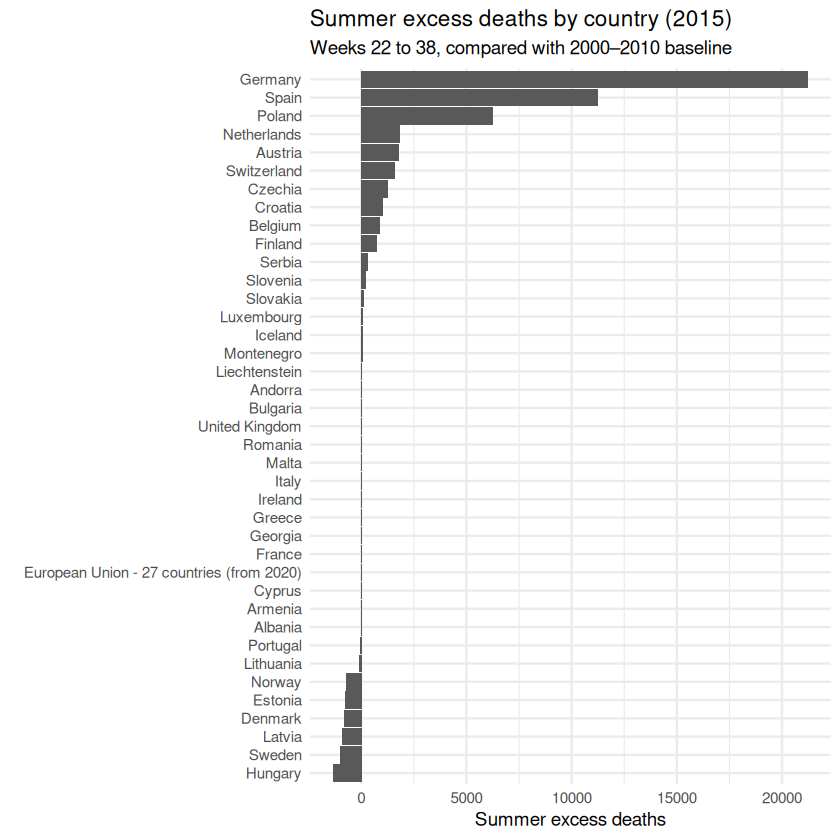

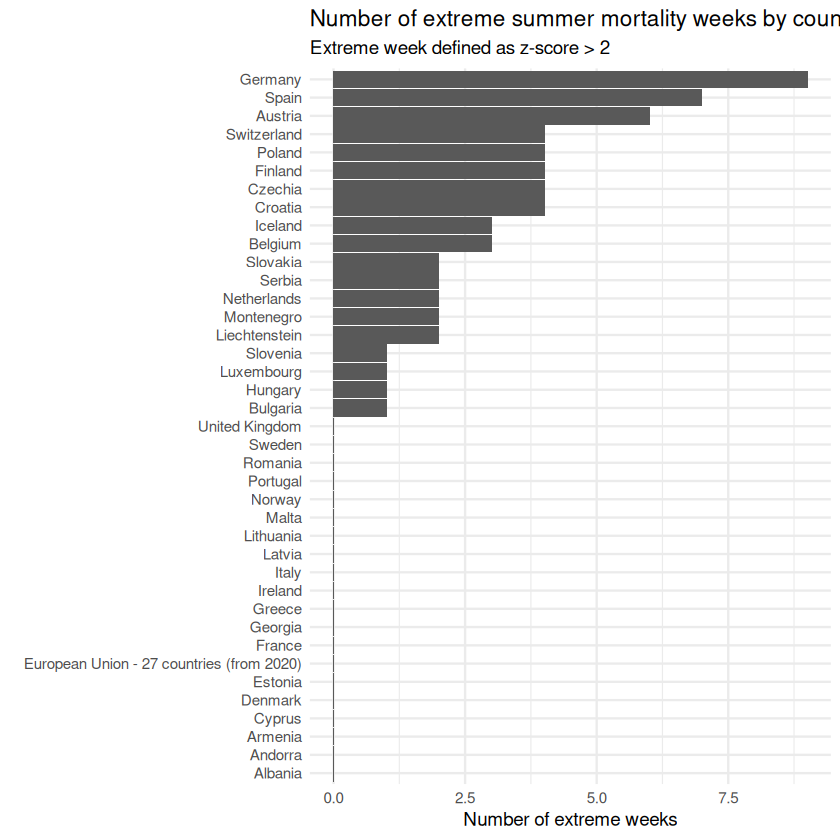

In [20]:
# Visualizations for 2015 heatwave

library(dplyr)
library(ggplot2)
library(forcats)

baseline <- deaths_long |>
  filter(year >= 2000, year <= 2010) |>
  group_by(geo_code, geo_label, week_num) |>
  summarise(
    baseline_mean = mean(deaths, na.rm = TRUE),
    baseline_sd   = sd(deaths, na.rm = TRUE),
    .groups = "drop"
  )

deaths_excess <- deaths_long |>
  left_join(baseline, by = c("geo_code", "geo_label", "week_num")) |>
  mutate(
    excess_deaths = deaths - baseline_mean,
    z_score = (deaths - baseline_mean) / baseline_sd
  )

summer_excess_2015 <- deaths_excess |>
  filter(year == 2015, week_num >= 22, week_num <= 38) |>
  group_by(geo_code, geo_label) |>
  summarise(
    summer_observed = sum(deaths, na.rm = TRUE),
    summer_expected = sum(baseline_mean, na.rm = TRUE),
    summer_excess   = sum(excess_deaths, na.rm = TRUE),
    pct_excess = 100 * (summer_observed - summer_expected) / summer_expected,
    max_weekly_excess = max(excess_deaths, na.rm = TRUE),
    avg_summer_z = mean(z_score, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(summer_excess))

summer_extremes_2015 <- deaths_excess |>
  filter(year == 2015, week_num >= 22, week_num <= 38) |>
  group_by(geo_code, geo_label) |>
  summarise(
    extreme_weeks = sum(z_score > 2, na.rm = TRUE),
    very_extreme_weeks = sum(z_score > 3, na.rm = TRUE),
    max_z = max(z_score, na.rm = TRUE),
    max_excess = max(excess_deaths, na.rm = TRUE),
    .groups = "drop"
  ) |>
  arrange(desc(extreme_weeks), desc(max_z))

print(summer_excess_2015)
print(summer_extremes_2015)

ggplot(summer_excess_2015, aes(x = reorder(geo_label, summer_excess), y = summer_excess)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Summer excess deaths by country (2015)",
    subtitle = "Weeks 22 to 38, compared with 2000–2010 baseline",
    x = NULL,
    y = "Summer excess deaths"
  ) +
  theme_minimal()

ggplot(summer_extremes_2015, aes(x = reorder(geo_label, extreme_weeks), y = extreme_weeks)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Number of extreme summer mortality weeks by country (2015)",
    subtitle = "Extreme week defined as z-score > 2",
    x = NULL,
    y = "Number of extreme weeks"
  ) +
  theme_minimal()

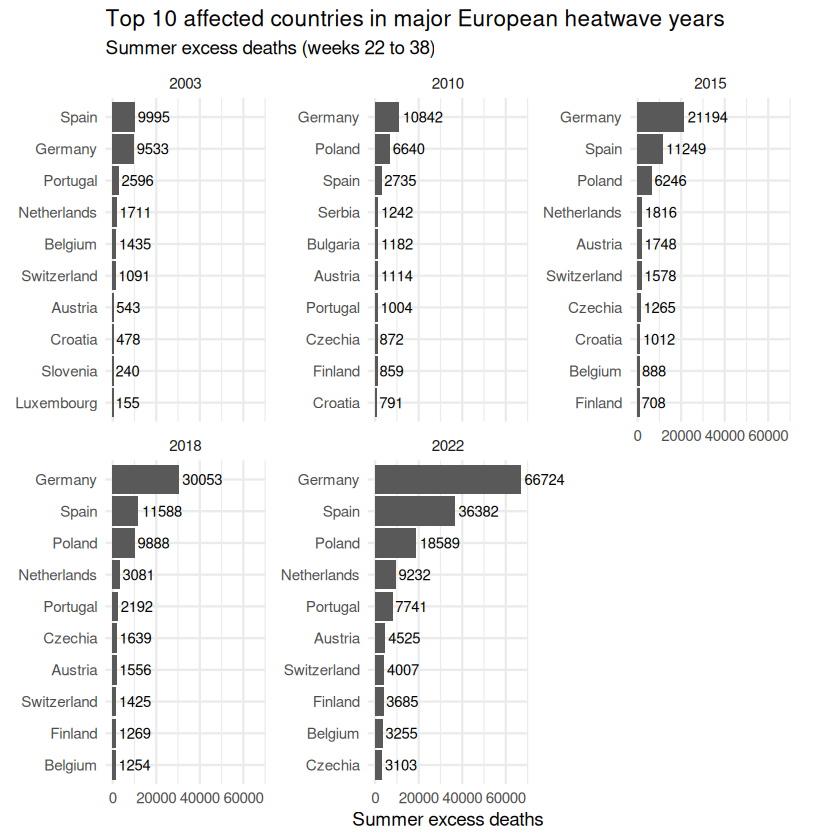

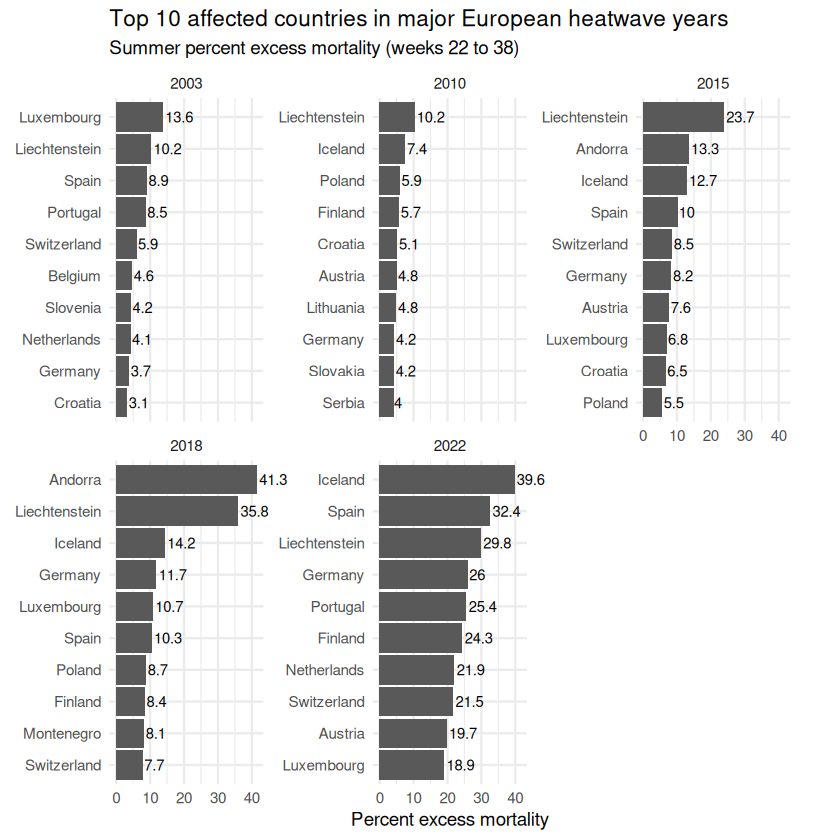

In [21]:

# Top 10 countries for each heatwave year
library(dplyr)
library(ggplot2)
library(tidytext)

heatwave_years <- c(2003, 2010, 2015, 2018, 2022)

summer_by_year <- deaths_excess |>
  filter(year %in% heatwave_years, week_num >= 22, week_num <= 38) |>
  group_by(year, geo_code, geo_label) |>
  summarise(
    summer_observed = sum(deaths, na.rm = TRUE),
    summer_expected = sum(baseline_mean, na.rm = TRUE),
    summer_excess   = sum(excess_deaths, na.rm = TRUE),
    pct_excess = 100 * (summer_observed - summer_expected) / summer_expected,
    .groups = "drop"
  )

top10_raw <- summer_by_year |>
  group_by(year) |>
  slice_max(order_by = summer_excess, n = 10, with_ties = FALSE) |>
  ungroup()

top10_pct <- summer_by_year |>
  filter(!is.na(pct_excess), is.finite(pct_excess)) |>
  group_by(year) |>
  slice_max(order_by = pct_excess, n = 10, with_ties = FALSE) |>
  ungroup()

# Plot 1: raw summer excess deaths
ggplot(top10_raw,
       aes(x = reorder_within(geo_label, summer_excess, year),
           y = summer_excess)) +
  geom_col() +
  geom_text(aes(label = round(summer_excess, 0)),
            hjust = -0.1, size = 3) +
  coord_flip(clip = "off") +
  scale_x_reordered() +
  facet_wrap(~ year, scales = "free_y") +
  labs(
    title = "Top 10 affected countries in major European heatwave years",
    subtitle = "Summer excess deaths (weeks 22 to 38)",
    x = NULL,
    y = "Summer excess deaths"
  ) +
  theme_minimal() +
  theme(plot.margin = margin(5.5, 30, 5.5, 5.5))

# Plot 2: summer percent excess mortality
ggplot(top10_pct,
       aes(x = reorder_within(geo_label, pct_excess, year),
           y = pct_excess)) +
  geom_col() +
  geom_text(aes(label = round(pct_excess, 1)),
            hjust = -0.1, size = 3) +
  coord_flip(clip = "off") +
  scale_x_reordered() +
  facet_wrap(~ year, scales = "free_y") +
  labs(
    title = "Top 10 affected countries in major European heatwave years",
    subtitle = "Summer percent excess mortality (weeks 22 to 38)",
    x = NULL,
    y = "Percent excess mortality"
  ) +
  theme_minimal() +
  theme(plot.margin = margin(5.5, 30, 5.5, 5.5))

In [22]:
# Export the plot

ggsave("top10_heatwave_years_raw.png", width = 12, height = 8, dpi = 300)
ggsave("top10_heatwave_years_percent.png", width = 12, height = 8, dpi = 300)

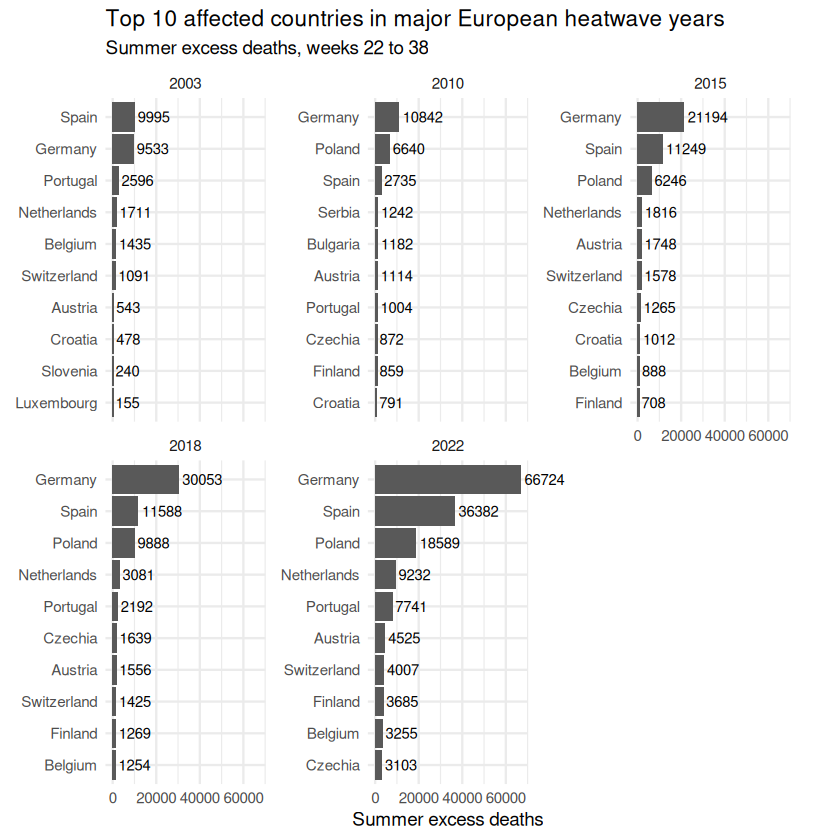

In [23]:
ggplot(top10_raw,
       aes(x = reorder_within(geo_label, summer_excess, year),
           y = summer_excess)) +
  geom_col() +
  geom_text(aes(label = round(summer_excess, 0)),
            hjust = -0.1, size = 3) +
  coord_flip(clip = "off") +
  scale_x_reordered() +
  facet_wrap(~ year, scales = "free_y") +
  labs(
    title = "Top 10 affected countries in major European heatwave years",
    subtitle = "Summer excess deaths, weeks 22 to 38",
    x = NULL,
    y = "Summer excess deaths"
  ) +
  theme_minimal() +
  theme(plot.margin = margin(5.5, 30, 5.5, 5.5))

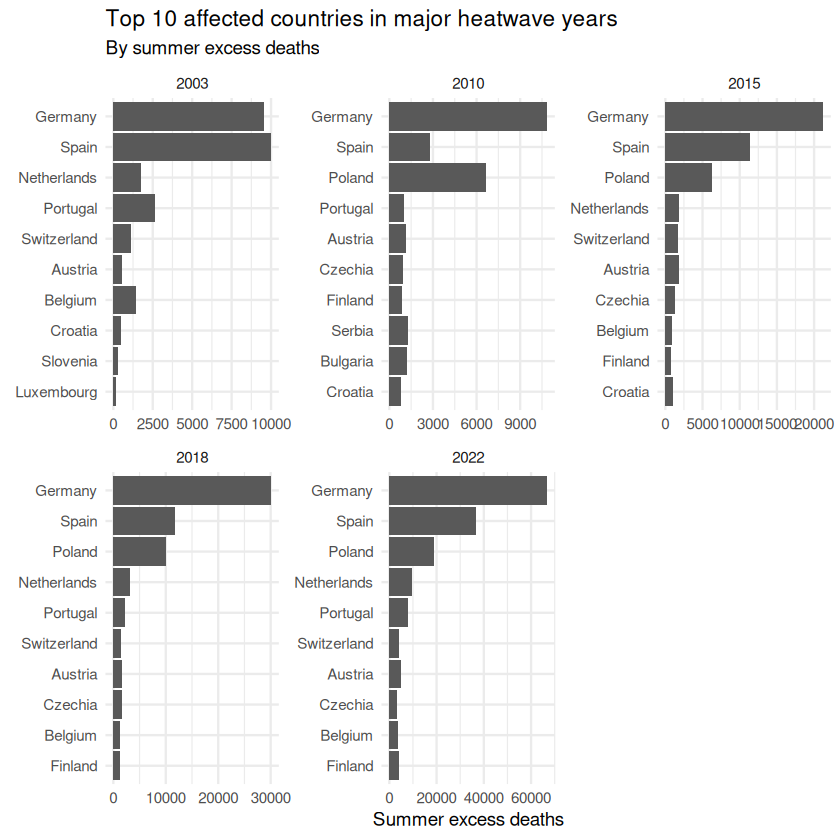

In [24]:

p_raw_simple <- top10_raw |>
  ggplot(aes(x = reorder(geo_label, summer_excess), y = summer_excess)) +
  geom_col() +
  coord_flip() +
  facet_wrap(~ year, scales = "free") +
  labs(
    title = "Top 10 affected countries in major heatwave years",
    subtitle = "By summer excess deaths",
    x = NULL,
    y = "Summer excess deaths"
  ) +
  theme_minimal()

print(p_raw_simple)

ggsave("top10_heatwave_years_raw_simple.png", plot = p_raw_simple, width = 12, height = 8, dpi = 300, bg = "white")

## Ethical Considerations

- Privacy: The dataset does not contain personal data.
- Governance: Data used is openly available and ethically sourced.
- Bias: Consideration of potential biases in dataset and analysis.

